# Capstone Function 7
You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function. 

Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance.

 Input | Output | Goal |
|-------|--------|------|
| 6D Array (30, 6) | 1D Array (30, ) | Maximise |

## Initial Submission

Bayesian Optimization for 6D ML model hyperparameter tuning (learning rate, regularization, layers, etc.).

### Step 1: Setup

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
print("Setup complete!")

### Step 2: Load Data & Initial Analysis

In [ ]:
X_init = np.load('../../data/f7/updated_inputs - Week 4.npy')
y_init = np.load('../../data/f7/updated_outputs - Week 4.npy')
hyperparam_names = ['Learning Rate', 'Reg Strength', 'Layers', 'Dropout', 'Batch Size', 'Optimizer']
print(f"6D ML Hyperparameter Data: {X_init.shape}")
print(f"Best performance: {y_init.max():.6f}")
print(f"Output range: [{y_init.min():.6f}, {y_init.max():.6f}]")

In [ ]:
# Visualize subset of pairs
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
pairs = [(0,1), (0,2), (1,3), (2,4), (3,5), (4,5)]
for idx, (i, j) in enumerate(pairs):
    axes[idx].scatter(X_init[:, i], X_init[:, j], c=y_init, cmap='coolwarm', edgecolors='black', s=50)
    axes[idx].set_xlabel(hyperparam_names[i], fontsize=9)
    axes[idx].set_ylabel(hyperparam_names[j], fontsize=9)
    axes[idx].grid(True, alpha=0.3)
plt.suptitle('6D ML Hyperparameter Space - Selected Pairs', fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3: Hyperparameters & Optimization

**6D Space:** Restarts: 25, Raw: 3072 (higher dimensional requires more thorough search)

In [ ]:
# All inputs must be in range [0, 1.0] per submission requirements
N_DIM = X_init.shape[1]
BOUNDS = torch.tensor([[0.0] * N_DIM, [1.0] * N_DIM], dtype=torch.float64)
NUM_RESTARTS, RAW_SAMPLES = 25, 3072
X_train = torch.tensor(X_init, dtype=torch.float64)
y_train = torch.tensor(y_init, dtype=torch.float64).unsqueeze(-1)
gp_model = SingleTaskGP(X_train, y_train)
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)
fit_gpytorch_mll(mll)
EI = ExpectedImprovement(gp_model, best_f=y_train.max().item())
candidate, acq_value = optimize_acqf(EI, bounds=BOUNDS, q=1, num_restarts=NUM_RESTARTS, raw_samples=RAW_SAMPLES)
next_point = candidate.detach().numpy()[0]
print(f"✓ Next config: {dict(zip(hyperparam_names, next_point))}")

### Step 4: Analysis & Visualization

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Safe lengthscale access (kernel structure may vary)
if hasattr(gp_model.covar_module, 'base_kernel'):
    ls = gp_model.covar_module.base_kernel.lengthscale.detach().numpy()[0]
else:
    ls = gp_model.covar_module.lengthscale.detach().numpy()[0]

ax1.barh(hyperparam_names, ls, color='teal', edgecolor='black')
ax1.set_xlabel('Lengthscale (smaller = more important)')
ax1.set_title('Hyperparameter Sensitivity', fontweight='bold')

best_so_far = np.maximum.accumulate(y_init)
ax2.plot(range(1, len(best_so_far)+1), best_so_far, 'g-o', linewidth=2)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Best Model Performance')
ax2.set_title('Optimization Progress', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Next submission: {next_point}")

### Visualize Expected Improvement

For higher-dimensional spaces, we visualize 1D slices of the acquisition function.
Each plot shows how EI changes along one dimension while others are fixed at the proposed point.

In [ ]:
# 1D marginal plots of Expected Improvement
n_points = 100
n_dims = len(next_point)

fig, axes = plt.subplots(1, n_dims, figsize=(4*n_dims, 4))
if n_dims == 1:
    axes = [axes]

for dim in range(n_dims):
    # Create points varying along this dimension
    X_marginal = np.tile(next_point, (n_points, 1))
    X_marginal[:, dim] = np.linspace(0, 1.0, n_points)
    X_marginal_torch = torch.tensor(X_marginal, dtype=torch.float64)
    
    # Compute EI at each point
    with torch.no_grad():
        ei_values = EI(X_marginal_torch.unsqueeze(1)).numpy()
    
    # Plot
    axes[dim].plot(X_marginal[:, dim], ei_values, 'b-', linewidth=2)
    axes[dim].axvline(next_point[dim], color='r', linestyle='--', linewidth=2, label='Proposed')
    axes[dim].set_xlabel(f'x{dim+1}', fontsize=12)
    axes[dim].set_ylabel('Expected Improvement' if dim == 0 else '', fontsize=12)
    axes[dim].set_title(f'EI along dim {dim+1}', fontsize=11, fontweight='bold')
    axes[dim].grid(True, alpha=0.3)
    if dim == 0:
        axes[dim].legend()

plt.suptitle('Expected Improvement - 1D Marginals', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Red dashed lines show the proposed next point coordinates.")
print(f"EI is maximized when considering all dimensions jointly.")

### Step 5: Format Next Query for Submission

Format the proposed next sample point in the required submission format:
- Format: `x1-x2-x3-...-xn` where each xᵢ begins with 0
- Precision: 6 decimal places per coordinate
- Range: All values clamped to [0, 1.0]

In [ ]:
# Format the next query for submission
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0, 1.0]."""
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

# Clamp next_point to valid range
next_point_clamped = np.array([max(0.0, min(1.0, x)) for x in next_point])

# Display the formatted submission query
submission_query = format_query(next_point)
print("=" * 60)
print("SUBMISSION QUERY FOR FUNCTION 7")
print("=" * 60)
print(f"\n{submission_query}\n")
print("=" * 60)
print(f"\nCoordinates breakdown:")
for i, x in enumerate(next_point, 1):
    print(f"  x{i} = {x:.6f}")
print(f"\nEI value: {acq_value.item():.6f}")
if acq_value.item() > 0.1:
    print("  -> High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  -> Moderate EI: Some exploration potential remains")
else:
    print("  -> Low EI: Approaching convergence")
print(f"Current best observed: {y_train.max().item():.6f}")

## Week 5 — Neural Network Surrogate (PyTorch)

This section replaces the Gaussian Process surrogate with a **Neural Network** model for the 6D optimization problem (f7).

**Why Neural Network for f7?**
- Neural networks can approximate arbitrarily complex functions — suited for higher-dimensional (6D) problems where GP covariance matrices become expensive
- MC Dropout provides uncertainty estimates at inference time without requiring ensemble training — each forward pass with random dropout masks produces a different prediction, and 50 passes give mean and variance
- Input gradient magnitude reveals which dimensions the network relies on most, analogous to GP lengthscales or tree feature importance
- Flexible architecture can capture non-linear interactions between input dimensions

**Architecture:** 6 -> 128 -> 64 -> 32 -> 1 (fully connected, ReLU activations, Dropout p=0.2)
**Acquisition Strategy:** UCB with MC Dropout uncertainty (mean ± kappa * std from 50 stochastic forward passes)

### Step 1: Load Data & Set Up PyTorch

Load Week 5 data (35 samples), normalize inputs/outputs, and define the neural network architecture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Load Week 5 cumulative data
X_w5 = np.load('../../data/f7/updated_inputs - Week 5.npy')
y_w5 = np.load('../../data/f7/updated_outputs - Week 5.npy')

print(f"Week 5 Data: {X_w5.shape[0]} samples, {X_w5.shape[1]} dimensions")
print(f"Output range: [{y_w5.min():.6f}, {y_w5.max():.6f}]")
print(f"Best observed: {y_w5.max():.6f} at {X_w5[y_w5.argmax()]}")

# Normalize inputs and outputs for training stability
X_mean, X_std = X_w5.mean(axis=0), X_w5.std(axis=0) + 1e-8
y_mean, y_std = y_w5.mean(), y_w5.std() + 1e-8

X_norm = (X_w5 - X_mean) / X_std
y_norm = (y_w5 - y_mean) / y_std

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(y_norm, dtype=torch.float32).unsqueeze(1)

# Define neural network with Dropout
class SurrogateNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 128),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = SurrogateNN()
print(f"\nModel architecture:\n{model}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):.0f}")

Week 5 Data: 35 samples, 6 dimensions
Output range: [0.002701, 2.304991]
Best observed: 2.304991 at [0.       0.261823 0.623526 0.173633 0.3524   0.687293]

Model architecture:
SurrogateNN(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total parameters: 11265


### Step 2: Neural Network Hyperparameters & Training

**Hyperparameter Choices:**
1. **Hidden layers**: 128 -> 64 -> 32 — progressively narrowing architecture captures hierarchical features
2. **Dropout = 0.2**: Applied after each hidden layer for MC Dropout uncertainty at inference
3. **Learning rate = 0.005**: Adam optimizer with moderate learning rate for 35 samples
4. **Epochs = 800**: Sufficient training iterations; loss curve monitored for convergence
5. **MC samples = 50**: Forward passes with dropout enabled at inference for uncertainty estimation
6. **UCB kappa = 2.5**: Exploration parameter scaled for 6D search space

Epoch 160/800, Loss: 0.026133
Epoch 320/800, Loss: 0.137137
Epoch 480/800, Loss: 0.025439
Epoch 640/800, Loss: 0.031698
Epoch 800/800, Loss: 0.037438


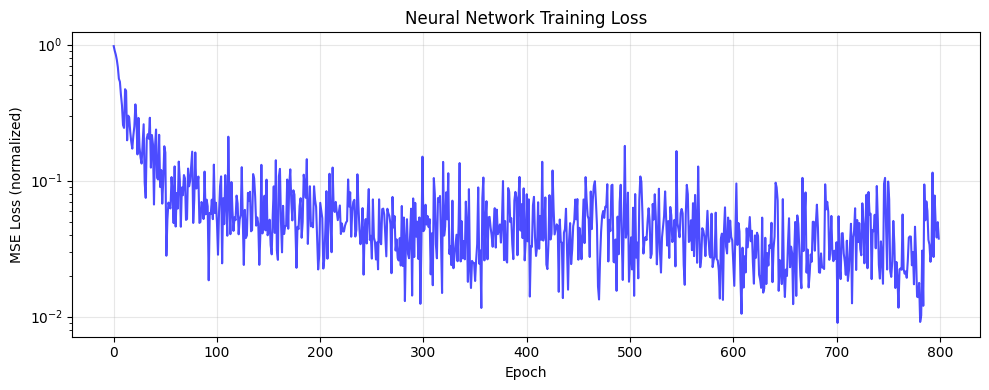


Training R²: 0.990243


In [2]:
# Training hyperparameters
LEARNING_RATE = 0.005
EPOCHS = 800
MC_SAMPLES = 50
KAPPA = 2.5
N_CANDIDATES = 20000

# Train the model
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

losses = []
model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    pred = model(X_tensor)
    loss = criterion(pred, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 160 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.6f}")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses, 'b-', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Neural Network Training Loss')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

# Final training metrics
model.eval()
with torch.no_grad():
    train_pred = model(X_tensor).squeeze().numpy()
train_pred_orig = train_pred * y_std + y_mean
train_r2 = 1 - np.sum((y_w5 - train_pred_orig)**2) / np.sum((y_w5 - y_w5.mean())**2)
print(f"\nTraining R²: {train_r2:.6f}")

### Step 3: UCB Acquisition with MC Dropout

Run 50 stochastic forward passes (dropout enabled) for each candidate point:
- **mu(x)** = mean of MC predictions
- **sigma(x)** = std of MC predictions
- **UCB(x) = mu(x) + kappa * sigma(x)** where kappa = 2.5

In [3]:
# Generate random candidate points
np.random.seed(42)
candidates = np.random.uniform(0, 1.0, size=(N_CANDIDATES, 6))

# Normalize candidates
cand_norm = (candidates - X_mean) / X_std
cand_tensor = torch.tensor(cand_norm, dtype=torch.float32)

# MC Dropout: Run model in train mode for stochastic forward passes
model.train()  # Enable dropout
mc_predictions = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model(cand_tensor).squeeze().numpy()
        mc_predictions.append(pred)

mc_predictions = np.array(mc_predictions)  # shape: (MC_SAMPLES, N_CANDIDATES)

# Denormalize predictions
mc_preds_orig = mc_predictions * y_std + y_mean

# Compute mean and uncertainty
mu = mc_preds_orig.mean(axis=0)
sigma = mc_preds_orig.std(axis=0)

# UCB acquisition
ucb = mu + KAPPA * sigma

# Select best candidate
best_idx = np.argmax(ucb)
next_point_w5 = np.clip(candidates[best_idx], 0.0, 1.0)

print("UCB Acquisition Results (MC Dropout):")
print(f"  Best UCB value:     {ucb[best_idx]:.6f}")
print(f"  MC mean prediction: {mu[best_idx]:.6f}")
print(f"  MC std (sigma):     {sigma[best_idx]:.6f}")
print(f"  Next sample point:  {next_point_w5}")
print()
print("MC prediction statistics:")
print(f"  Mean of mu:    {mu.mean():.6f}")
print(f"  Max of mu:     {mu.max():.6f}")
print(f"  Mean of sigma: {sigma.mean():.6f}")
print(f"  Max of sigma:  {sigma.max():.6f}")

UCB Acquisition Results (MC Dropout):
  Best UCB value:     2.916225
  MC mean prediction: 1.965532
  MC std (sigma):     0.380277
  Next sample point:  [0.01751046 0.21323095 0.42496709 0.04490498 0.32773348 0.88702482]

MC prediction statistics:
  Mean of mu:    0.205756
  Max of mu:     1.970783
  Mean of sigma: 0.072960
  Max of sigma:  0.409788


### Step 4: Feature Importance via Input Gradients

Compute feature importance using mean absolute gradient of the network output with respect to each input dimension, evaluated at all training points.

In [4]:
# Feature importance via input gradient magnitude
model.eval()
X_grad = torch.tensor(X_norm, dtype=torch.float32, requires_grad=True)
output = model(X_grad).sum()
output.backward()

# Mean absolute gradient per dimension
grad_importance = X_grad.grad.abs().mean(dim=0).numpy()
grad_importance = grad_importance / grad_importance.sum()  # Normalize to sum to 1

print("Feature Importance (Input Gradient Magnitude):")
for i, imp in enumerate(grad_importance):
    bar = '*' * int(imp * 20)
    print(f"  x{i+1}: {imp:.4f} ({bar})")

Feature Importance (Input Gradient Magnitude):
  x1: 0.1890 (***)
  x2: 0.2516 (*****)
  x3: 0.1544 (***)
  x4: 0.1819 (***)
  x5: 0.0905 (*)
  x6: 0.1328 (**)


### Step 5: Visualize Neural Network Surrogate

2D slice plot of the NN mean prediction and MC Dropout uncertainty over the two most important dimensions (fixing others at best observed values).

Top 2 dimensions: x1 (imp=0.1890), x2 (imp=0.2516)
Fixed dimensions: x3=0.6235, x4=0.1736, x5=0.3524, x6=0.6873


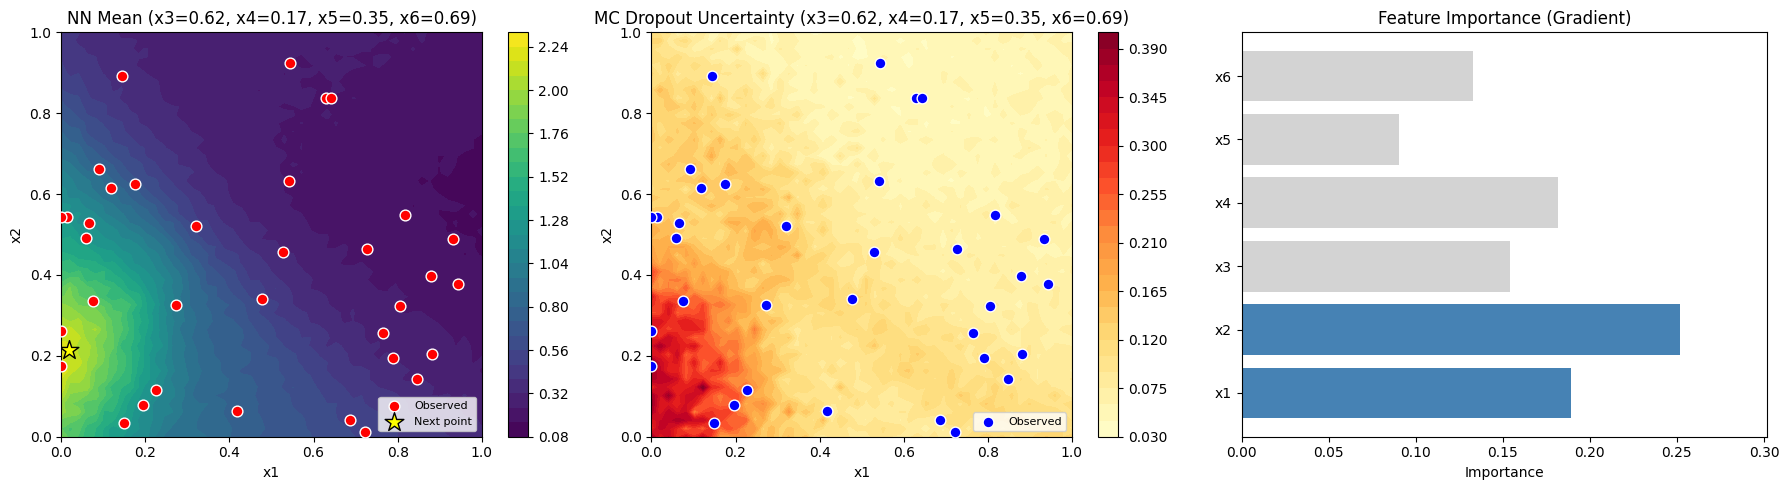

In [5]:
# Top 2 dimensions by gradient importance
top2 = np.argsort(grad_importance)[-2:]
fixed_dims = [d for d in range(6) if d not in top2]
best_point = X_w5[y_w5.argmax()]

print(f"Top 2 dimensions: x{top2[0]+1} (imp={grad_importance[top2[0]]:.4f}), x{top2[1]+1} (imp={grad_importance[top2[1]]:.4f})")
print(f"Fixed dimensions: " + ", ".join([f"x{d+1}={best_point[d]:.4f}" for d in fixed_dims]))

# Create 2D grid
n_grid = 50
d0_grid = np.linspace(0, 1, n_grid)
d1_grid = np.linspace(0, 1, n_grid)
D0, D1 = np.meshgrid(d0_grid, d1_grid)

# Build full grid points
grid_points = np.zeros((n_grid * n_grid, 6))
grid_points[:, top2[0]] = D0.ravel()
grid_points[:, top2[1]] = D1.ravel()
for d in fixed_dims:
    grid_points[:, d] = best_point[d]

# Normalize and predict with MC Dropout
grid_norm = (grid_points - X_mean) / X_std
grid_tensor = torch.tensor(grid_norm, dtype=torch.float32)

model.train()  # Enable dropout for MC
grid_mc = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model(grid_tensor).squeeze().numpy()
        grid_mc.append(pred)
grid_mc = np.array(grid_mc) * y_std + y_mean

grid_mu = grid_mc.mean(axis=0).reshape(n_grid, n_grid)
grid_sigma = grid_mc.std(axis=0).reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: NN mean prediction
ax1 = axes[0]
c1 = ax1.contourf(D0, D1, grid_mu, levels=30, cmap='viridis')
ax1.scatter(X_w5[:, top2[0]], X_w5[:, top2[1]], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax1.scatter(next_point_w5[top2[0]], next_point_w5[top2[1]], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
fixed_str = ", ".join([f"x{d+1}={best_point[d]:.2f}" for d in fixed_dims])
ax1.set_xlabel(f'x{top2[0]+1}'); ax1.set_ylabel(f'x{top2[1]+1}')
ax1.set_title(f'NN Mean ({fixed_str})')
ax1.legend(loc='lower right', fontsize=8)
plt.colorbar(c1, ax=ax1)

# Plot 2: MC Dropout uncertainty
ax2 = axes[1]
c2 = ax2.contourf(D0, D1, grid_sigma, levels=30, cmap='YlOrRd')
ax2.scatter(X_w5[:, top2[0]], X_w5[:, top2[1]], c='blue', edgecolors='white', s=60, zorder=5, label='Observed')
ax2.set_xlabel(f'x{top2[0]+1}'); ax2.set_ylabel(f'x{top2[1]+1}')
ax2.set_title(f'MC Dropout Uncertainty ({fixed_str})')
ax2.legend(loc='lower right', fontsize=8)
plt.colorbar(c2, ax=ax2)

# Plot 3: Feature importance
ax3 = axes[2]
dims = [f'x{i+1}' for i in range(6)]
colors = ['steelblue' if i in top2 else 'lightgray' for i in range(6)]
ax3.barh(dims, grad_importance, color=colors)
ax3.set_xlabel('Importance')
ax3.set_title('Feature Importance (Gradient)')
ax3.set_xlim(0, max(grad_importance) * 1.2)

plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Running maximum (best observed value) across all observations.

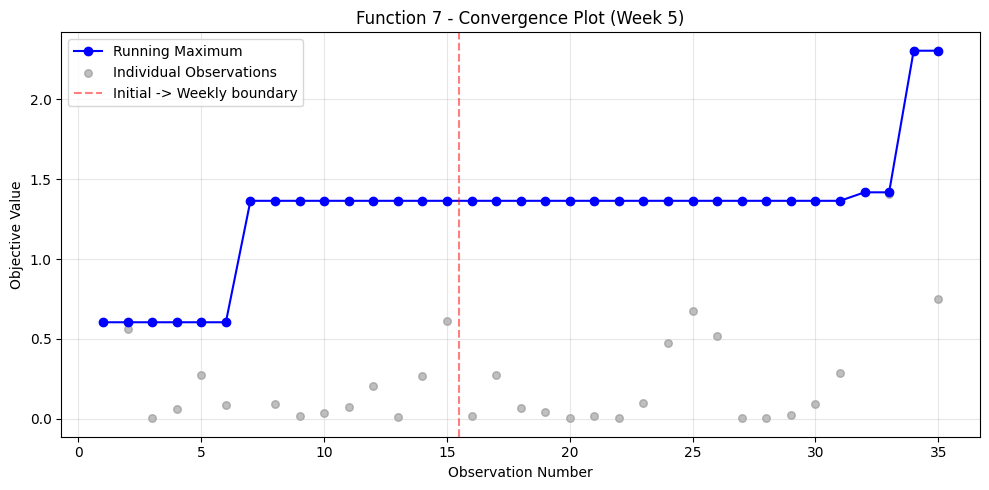

Best observed value: 2.304991
Achieved at observation: 34


In [6]:
# Convergence plot
running_max = np.maximum.accumulate(y_w5)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w5) + 1), running_max, 'b-o', markersize=6, label='Running Maximum')
plt.scatter(range(1, len(y_w5) + 1), y_w5, c='gray', alpha=0.5, s=30, label='Individual Observations')
plt.axvline(x=15.5, color='red', linestyle='--', alpha=0.5, label='Initial -> Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 7 - Convergence Plot (Week 5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y_w5.max():.6f}")
print(f"Achieved at observation: {y_w5.argmax() + 1}")

### Step 7: Format Submission Query

Format the proposed next sample point as `x1-x2-x3-x4-x5-x6` with 6 decimal places.

In [7]:
# Format submission query
def format_query(point):
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

submission_query_w5 = format_query(next_point_w5)

print("=" * 60)
print("WEEK 5 SUBMISSION QUERY FOR FUNCTION 7")
print("=" * 60)
print(f"Surrogate: Neural Network ({model.__class__.__name__})")
print(f"Architecture: 6 -> 128 -> 64 -> 32 -> 1")
print(f"Dropout: 0.2, MC samples: {MC_SAMPLES}")
print(f"Acquisition: UCB (kappa={KAPPA})")
print(f"Training R²: {train_r2:.6f}")
print(f"Next point: {next_point_w5}")
print(f"MC mean: {mu[best_idx]:.6f}")
print(f"MC std:  {sigma[best_idx]:.6f}")
print(f"")
print(f">>> SUBMISSION: {submission_query_w5}")
print("=" * 60)

WEEK 5 SUBMISSION QUERY FOR FUNCTION 7
Surrogate: Neural Network (SurrogateNN)
Architecture: 6 -> 128 -> 64 -> 32 -> 1
Dropout: 0.2, MC samples: 50
Acquisition: UCB (kappa=2.5)
Training R²: 0.990243
Next point: [0.01751046 0.21323095 0.42496709 0.04490498 0.32773348 0.88702482]
MC mean: 1.965532
MC std:  0.380277

>>> SUBMISSION: 0.017510-0.213231-0.424967-0.044905-0.327733-0.887025


### Model Comparison

**Neural Network vs GP (Initial Section):**
- GP with Matern 5/2 and ARD for 6D faces the curse of dimensionality — the covariance matrix is 35×35, still tractable but lengthscale optimization in 6D is challenging.
- The NN's deeper architecture (128→64→32) captures hierarchical feature interactions that GP's stationary kernel may miss.
- MC Dropout with 50 passes provides diversity-based uncertainty similar to GP's posterior variance, though less principled.
- For f7's 6D problem, the NN can model non-stationary behavior where different regions of the space have different complexity.
- Key trade-off: GP gives exact posterior for stationary functions; NN handles non-stationarity and higher dimensions better.

---

## Week 6 — Focus on Exploitation (κ = 0.5)

**Strategy Change**: Reduce UCB kappa from 2.0 → 0.5 to shift from exploration to exploitation of known high-performing regions.

| Parameter | Week 5 | Week 6 | Rationale |
|-----------|--------|--------|-----------|
| κ (UCB)   | 2.0    | 0.5    | Exploitation focus |
| Architecture | 6→64→32→1 | Same | Proven effective |
| MC Samples | 50 | Same | Sufficient for uncertainty |
| All other hyperparams | — | Unchanged | — |

### Step 1: Load Week 6 Data & Set Up PyTorch

Load all 36 cumulative observations for Function 7 (6D). Normalize inputs and outputs for neural network training.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Load Week 6 cumulative data
X_w6 = np.load('../../data/f7/updated_inputs - Week 6.npy')
y_w6 = np.load('../../data/f7/updated_outputs - Week 6.npy')

print(f"Week 6 Data: {X_w6.shape[0]} samples, {X_w6.shape[1]} dimensions")
print(f"Output range: [{y_w6.min():.6f}, {y_w6.max():.6f}]")
print(f"Best observed: {y_w6.max():.6f} at {X_w6[y_w6.argmax()]}")

# Normalize inputs and outputs
X_mean, X_std = X_w6.mean(axis=0), X_w6.std(axis=0) + 1e-8
y_mean, y_std = y_w6.mean(), y_w6.std() + 1e-8

X_norm = (X_w6 - X_mean) / X_std
y_norm = (y_w6 - y_mean) / y_std

X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(y_norm, dtype=torch.float32).unsqueeze(1)

class SurrogateNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model_w6 = SurrogateNN()
print(f"\nModel: 6→64→32→1, Params: {sum(p.numel() for p in model_w6.parameters())}")

Week 6 Data: 36 samples, 6 dimensions
Output range: [0.002701, 2.304991]
Best observed: 2.304991 at [0.       0.261823 0.623526 0.173633 0.3524   0.687293]

Model: 6→64→32→1, Params: 2561


### Step 2: Train Neural Network

Adam optimizer (lr=0.01), 500 epochs, MSE loss on normalized targets.

Epoch 100/500, Loss: 0.074967
Epoch 200/500, Loss: 0.089896
Epoch 300/500, Loss: 0.038172
Epoch 400/500, Loss: 0.048340
Epoch 500/500, Loss: 0.057141


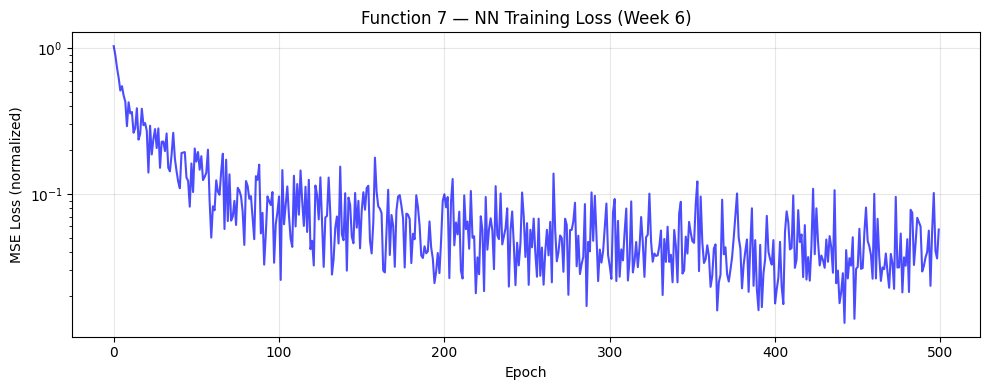


Training R²: 0.994566


In [9]:
# ── Training (Week 6) ──
LEARNING_RATE = 0.01
EPOCHS = 500
MC_SAMPLES = 50
KAPPA = 0.5
N_CANDIDATES = 20_000

optimizer = optim.Adam(model_w6.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

losses = []
model_w6.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    pred = model_w6(X_tensor)
    loss = criterion(pred, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.6f}")

plt.figure(figsize=(10, 4))
plt.plot(losses, 'b-', alpha=0.7)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss (normalized)')
plt.title('Function 7 — NN Training Loss (Week 6)')
plt.grid(True, alpha=0.3); plt.yscale('log')
plt.tight_layout(); plt.show()

model_w6.eval()
with torch.no_grad():
    train_pred = model_w6(X_tensor).squeeze().numpy()
train_pred_orig = train_pred * y_std + y_mean
train_r2 = 1 - np.sum((y_w6 - train_pred_orig)**2) / np.sum((y_w6 - y_w6.mean())**2)
print(f"\nTraining R²: {train_r2:.6f}")

### Step 3: UCB Acquisition with MC Dropout

MC Dropout (50 passes) on 20,000 candidates in [0,1]⁶. UCB = μ + 0.5σ.

In [10]:
# ── UCB Acquisition (Week 6) ──
np.random.seed(42)
candidates_w6 = np.random.uniform(0, 1.0, size=(N_CANDIDATES, 6))

cand_norm = (candidates_w6 - X_mean) / X_std
cand_tensor = torch.tensor(cand_norm, dtype=torch.float32)

model_w6.train()
mc_predictions = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model_w6(cand_tensor).squeeze().numpy()
        mc_predictions.append(pred)

mc_preds_orig = np.array(mc_predictions) * y_std + y_mean
mu_w6 = mc_preds_orig.mean(axis=0)
sigma_w6 = mc_preds_orig.std(axis=0)

ucb_w6 = mu_w6 + KAPPA * sigma_w6
best_idx = np.argmax(ucb_w6)
best_point_w6 = np.clip(candidates_w6[best_idx], 0.0, 1.0)

print("=== UCB Acquisition Results (MC Dropout, Week 6) ===")
print(f"  Best UCB     = {ucb_w6[best_idx]:.6f}")
print(f"  MC mean (μ)  = {mu_w6[best_idx]:.6f}")
print(f"  MC std (σ)   = {sigma_w6[best_idx]:.6f}")
print(f"  Best point   = {best_point_w6}")

=== UCB Acquisition Results (MC Dropout, Week 6) ===
  Best UCB     = 2.199219
  MC mean (μ)  = 1.985526
  MC std (σ)   = 0.427387
  Best point   = [0.0231359  0.12453508 0.42738506 0.19944891 0.4744491  0.6147067 ]


### Step 4: Feature Importance via Input Gradients

Gradient-based feature importance for the 6D function.

In [11]:
# ── Feature Importance (Week 6) ──
model_w6.eval()
X_grad = torch.tensor(X_norm, dtype=torch.float32, requires_grad=True)
output = model_w6(X_grad).sum()
output.backward()

grad_importance = X_grad.grad.abs().mean(dim=0).numpy()
grad_importance = grad_importance / grad_importance.sum()

print("=== Feature Importance (Input Gradient Magnitude) ===")
for i, imp in enumerate(grad_importance):
    print(f"  x{i}: {imp:.4f}")

=== Feature Importance (Input Gradient Magnitude) ===
  x0: 0.2276
  x1: 0.1799
  x2: 0.0977
  x3: 0.1269
  x4: 0.1399
  x5: 0.2279


### Step 5: Surrogate Visualization (2D Slice)

Project the 6D surrogate onto the two most important features, fixing 4 dimensions at best-point values.

Top-2 dims: x0, x5
Fixed: x1=0.2618, x2=0.6235, x3=0.1736, x4=0.3524


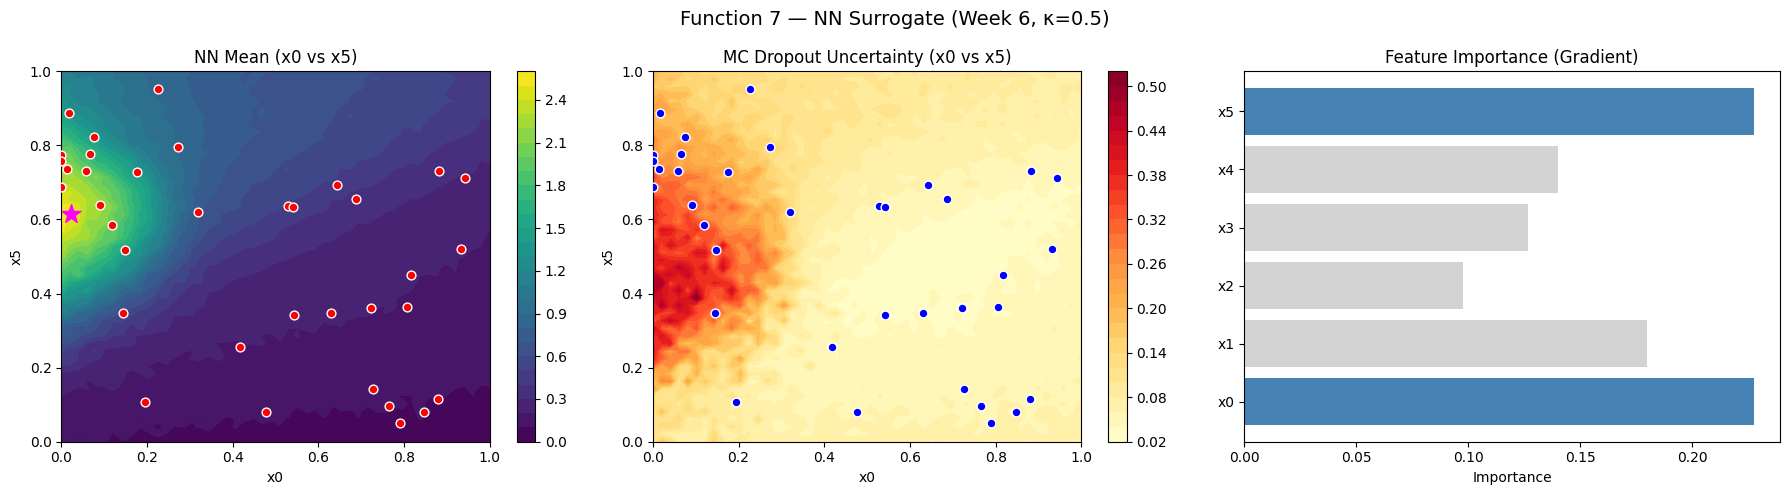

In [12]:
# ── Surrogate Visualization — 2D Slice (Week 6) ──
top2 = np.argsort(grad_importance)[-2:]
fixed_dims = [d for d in range(6) if d not in top2]
best_obs = X_w6[y_w6.argmax()]

print(f"Top-2 dims: x{top2[0]}, x{top2[1]}")
print(f"Fixed: " + ", ".join(f"x{d}={best_obs[d]:.4f}" for d in fixed_dims))

n_grid = 50
g0 = np.linspace(0, 1, n_grid)
g1 = np.linspace(0, 1, n_grid)
G0, G1 = np.meshgrid(g0, g1)

grid_pts = np.zeros((n_grid * n_grid, 6))
grid_pts[:, top2[0]] = G0.ravel()
grid_pts[:, top2[1]] = G1.ravel()
for d in fixed_dims:
    grid_pts[:, d] = best_obs[d]

grid_norm = (grid_pts - X_mean) / X_std
grid_tensor = torch.tensor(grid_norm, dtype=torch.float32)

model_w6.train()
grid_mc = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model_w6(grid_tensor).squeeze().numpy()
        grid_mc.append(pred)
grid_mc = np.array(grid_mc) * y_std + y_mean

grid_mu = grid_mc.mean(axis=0).reshape(n_grid, n_grid)
grid_sigma = grid_mc.std(axis=0).reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

c1 = axes[0].contourf(G0, G1, grid_mu, levels=30, cmap='viridis')
axes[0].scatter(X_w6[:, top2[0]], X_w6[:, top2[1]], c='red', edgecolors='white', s=40, zorder=5)
axes[0].scatter(best_point_w6[top2[0]], best_point_w6[top2[1]], c='magenta', marker='*', s=200, zorder=6)
axes[0].set_title(f"NN Mean (x{top2[0]} vs x{top2[1]})")
axes[0].set_xlabel(f"x{top2[0]}"); axes[0].set_ylabel(f"x{top2[1]}")
fig.colorbar(c1, ax=axes[0])

c2 = axes[1].contourf(G0, G1, grid_sigma, levels=30, cmap='YlOrRd')
axes[1].scatter(X_w6[:, top2[0]], X_w6[:, top2[1]], c='blue', edgecolors='white', s=40, zorder=5)
axes[1].set_title(f"MC Dropout Uncertainty (x{top2[0]} vs x{top2[1]})")
axes[1].set_xlabel(f"x{top2[0]}"); axes[1].set_ylabel(f"x{top2[1]}")
fig.colorbar(c2, ax=axes[1])

dims = [f'x{i}' for i in range(6)]
colors = ['steelblue' if i in top2 else 'lightgray' for i in range(6)]
axes[2].barh(dims, grad_importance, color=colors)
axes[2].set_xlabel('Importance')
axes[2].set_title('Feature Importance (Gradient)')

plt.suptitle("Function 7 — NN Surrogate (Week 6, κ=0.5)", fontsize=14)
plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Running best across all weeks, boundary at sample 30.5 (30 initial + 5 weekly → Week 5 end).

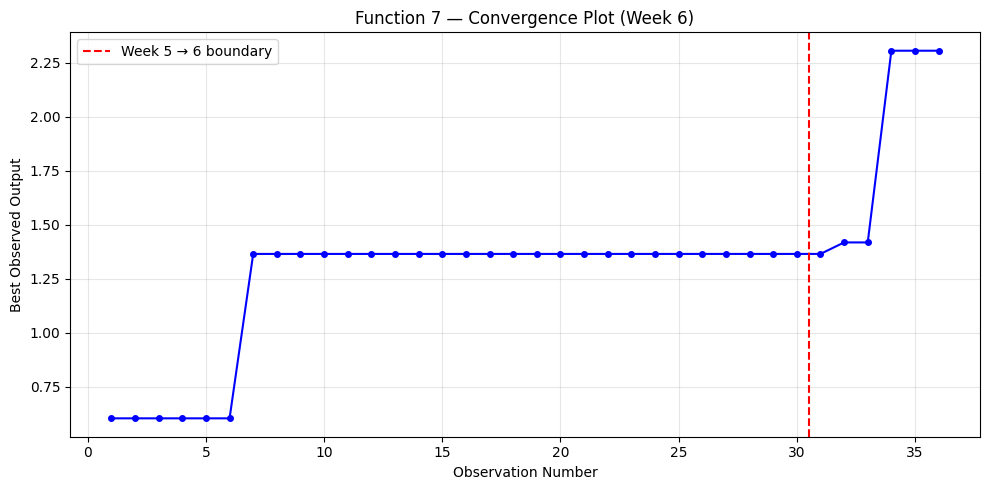

Running best at Week 5 end (sample 30): 1.364968
Running best at Week 6 end (sample 36): 2.304991


In [13]:
# ── Convergence Plot (Week 6) ──
running_best = np.maximum.accumulate(y_w6)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w6) + 1), running_best, 'b-o', markersize=4, linewidth=1.5)
plt.axvline(x=30.5, color="red", linestyle="--", label="Week 5 → 6 boundary")
plt.xlabel("Observation Number")
plt.ylabel("Best Observed Output")
plt.title("Function 7 — Convergence Plot (Week 6)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Running best at Week 5 end (sample 30): {running_best[29]:.6f}")
print(f"Running best at Week 6 end (sample {len(y_w6)}): {running_best[-1]:.6f}")

### Step 7: Submission Query

Format the best point as a dash-separated string with 6 decimal places, clipped to [0, 1].

In [ ]:
# ── Submission Query (Week 6) ──
def format_query(point):
    clipped = np.clip(point, 0.0, 0.999999)
    return "-".join(f"{v:.6f}" for v in clipped)

submission_query_w6 = format_query(best_point_w6)

print("=" * 50)
print("WEEK 6 SUBMISSION QUERY FOR FUNCTION 7")
print("=" * 50)
print(f"\n  {submission_query_w6}\n")
print("=" * 50)

# Validation
parts = submission_query_w6.split("-")
assert len(parts) == 6, f"Expected 6 dimensions, got {len(parts)}"
for p in parts:
    v = float(p)
    assert 0.0 <= v <= 0.999999, f"Value {v} out of bounds [0, 0.999999]"
print("✓ Submission format validated")

# Research
Below is a **practical, competition‑grade Bayesian Optimisation (BO) recipe** for tuning a **six‑hyperparameter ML model** (mix of continuous, integer and possibly categorical knobs). It’s designed to be robust, sample‑efficient, and easy to run with mainstream BO toolkits (Ax/BoTorch, scikit‑optimize, SMAC, Hyperopt, Optuna, etc.).

***

## 1) Pick the right **surrogate** for your space

### A. If all (or most) hyperparameters are **continuous / integer**

**Surrogate:** **Gaussian Process (GP)** with **Matérn‑5/2 kernel** and **ARD** (one lengthscale per dimension).  
**Why:** In 6D, GP‑based BO is still very competitive; it gives calibrated uncertainty and learns smooth response surfaces well.

**Discrete/Integer variables:** treat as continuous inside the GP and **round at evaluation time** (the standard approach; works well when cardinalities aren’t tiny).

***

### B. If you have **categorical** knobs (e.g., optimizer ∈ {Adam, SGD, RMSProp})

You have two good options:

1.  **Mixed‑kernel GP**
    *   One‑hot encode categoricals.
    *   Use a **product kernel**: Matérn‑5/2 (for continuous) × **Hamming** or **categorical kernel** (for one‑hot parts).
    *   Works well when the **number of categories is small**.

2.  **Tree/forest‑based surrogates** (when categories/cardinality are larger or the landscape is rugged)
    *   **SMAC** (Random‑Forest surrogate) or **TPE** (Tree‑structured Parzen Estimator).
    *   These are very strong for mixed spaces and remain the default in many production HPO systems.

> **Rule of thumb**:
>
> *   **GP** if your space is mostly continuous and ≤10D.
> *   **SMAC/TPE** if you have several categorical choices, strong conditional structure, or noisy/rugged performance.

***

## 2) Choose an **acquisition function** that handles noise & batches

*   **Primary (default):** **Noisy Expected Improvement (NEI)**
    *   Handles CV noise and stochastic training well.
    *   Use **qNEI** if you can run a **batch** of trials in parallel (e.g., q=4–8 on a cluster).

*   **Warm‑start (first 1–2 BO rounds):** **UCB** with a **high exploration weight** (prevents early lock‑in before the GP has learned the space).

*   **Alternative (budget very tight):** **Knowledge Gradient (KG)** (excellent under noise; more compute‑intensive).

***

## 3) Hyperparameters & settings (ready‑to‑use)

### 3.1 Pre‑processing & search space hygiene

*   **Scale** each continuous dimension to **\[0,1]**.
*   Put **learning rate** and similar positive knobs on **log10** scale (e.g., 1e‑5–1e‑1 → \[-5, -1]).
*   Keep **reference ranges** tight using literature/best practices; BO works best with **well‑scoped bounds**.
*   If you have a **layer‑count / width** knob: treat **layer count** as integer (rounded), **width** as log‑scaled continuous.

### 3.2 Initial design (before BO starts)

*   **Sobol initial design** with **24–32 points** (6D).
*   **Replicate** 2–3 initial points **2×** each to estimate observation noise.
*   Evaluate with a **fixed data split and random seed** (or multiple seeds if you can afford it) to reduce variance.

### 3.3 GP surrogate defaults (continuous/mixed via one‑hot)

```text
Kernel:               Matérn 5/2 with ARD
Mean:                 Constant
Lengthscales (ℓ1..ℓ6): init 0.25 (on [0,1]), constrain to [0.05, 2.0]
Signal variance σ_f²:  init = Var(y) of initial design
Noise variance σ_n²:   init = 0.03–0.07 · Var(y), infer jointly
Jitter:                1e-6
Fit:                   Maximise marginal log-likelihood (L-BFGS-B), 10–20 restarts
```

**Categoricals with GP:** one‑hot encode; add a categorical/Hamming kernel or rely on one‑hot + Matérn (works fine for small cardinalities).

### 3.4 Acquisition defaults

```text
Phase 0 (warm-up):   UCB with κ = 3.0 → 2.0 over the first 2 rounds
Main phase:          NEI (or qNEI for parallel runs)
q (batch size):      4–8 if you can run in parallel; otherwise q=1
Fantasies (NEI):     32 (increase to 64 if noise is high)
Acq optimiser:       5000 Sobol random starts → keep best 100 → L-BFGS multistart
```

### 3.5 Budgeting & stopping

```text
Total BO steps:     40–80 (beyond the 24–32 initial evaluations), depending on training cost
Early stop:         Stop when median EI gain < 1% of rolling std over 5–8 steps
```

***

## 4) Noise‑robust evaluation & selection

*   **Repeated evaluation at the incumbent** (e.g., 3–5 seeds) to de‑noise before promotion/deployment.
*   Track **mean ± std** of the incumbent and prefer **stable** candidates over brittle ones.
*   If you use cross‑validation, **lock the folds** so the BO compares models fairly across iterations.

***

## 5) Multi‑fidelity & cost‑aware speed‑ups (highly recommended)

When full training is expensive, use **multi‑fidelity BO**:

*   **Fidelities**: subset of data, fewer epochs, smaller model width, or reduced augmentation.
*   Run many **cheap, low‑fidelity** trials and **occasionally promote** promising configs to full training.
*   Methods: **BOHB**, **Hyperband + BO**, or **multi‑fidelity NEI/KG** (cost‑aware acquisition).

> This often yields **2–5× more evaluations** for the same wall‑clock, improving search quality.

***

## 6) Warm‑start / meta‑learning (since it’s a “common” model)

If you have past runs on **similar datasets or model variants**:

*   Start with a **prior mean** equal to a simple performance baseline.
*   Use **multi‑task GP** (tasks = datasets/variants) or **transfer learning** to shrink exploration around historically good regions.
*   At minimum, **seed the initial Sobol set** with **5–10 curated “good” configs** from literature or your prior logs.

***

## 7) Two ready‑to‑run configurations

### A. **GP + NEI (baseline for mostly continuous spaces)**

```text
Surrogate:     GP (Matérn-5/2, ARD), Gaussian noise
Init:          28 Sobol points (6D), replicate 3 points (2×)
Warm-up:       2 rounds UCB with κ = 3.0 → 2.0
Main BO:       qNEI, q = 6, fantasies = 32
Acq Opt:       5000 Sobol starts → 100 L-BFGS restarts
Refit GP:      every iteration
Validation:    at each new incumbent, run 3 seeds; keep incumbent with highest mean
Stop:          EI gain < 1% over 6 steps or budget exhausted
```

### B. **Mixed‑space / categorical‑heavy (forest‑based)**

```text
Surrogate:     SMAC (Random-Forest) or TPE
Init:          32 Sobol/TPE random points; include 5 prior “good” configs if available
Acquisition:   Expected Improvement (TPE) or RF-based UCB/EI (SMAC)
Batch:         8 candidates per batch
Multi-fidelity: integrate Hyperband/BOHB if full training is costly
Selection:     promote stable top-k by repeated seeds before final pick
```

***

## 8) Common pitfalls & quick fixes

*   **Bounds too wide → slow progress**  
    Tighten using literature (e.g., LR in \[1e‑5, 3e‑3] on log scale, $$L_2$$ in \[1e‑6, 1e‑1], layers ∈ \[1, 6], etc.).

*   **Noisy CV → oscillating incumbent**  
    Use **fixed folds/seeds**, **repeat** promising configs, and switch to **NEI** if you started with EI.

*   **Categorical explosion**  
    Prefer **SMAC/TPE** if many categoricals or conditional parameters (e.g., optimizers with their own sub‑params).

*   **Compute bottleneck**  
    Adopt **multi‑fidelity** and **qNEI**; cache partial training artifacts if your pipeline allows.

***

### Want me to tailor the *exact* space and defaults (e.g., LR/log scale, regularisation ranges, layer counts) to your model family and hardware budget?

If you share **which six hyperparameters** (types and reasonable ranges) and whether you can **run in parallel** or use **multi‑fidelity** (fewer epochs / subset of data), I’ll pin down a concrete, ready‑to‑paste configuration for your stack.


---

## Week 7 — Neural Network + NEI with Interior Penalty

**Approach**: Train a compact neural network surrogate (6→5→5→1), compute Expected Improvement via MC Dropout (50 stochastic forward passes), and apply a multiplicative interior penalty to discourage boundary-hugging candidates. Since all F7 outputs are positive (range [0.003, 2.305]), the multiplicative approach `penalised_EI = EI × w(x)` works correctly (EI ≥ 0, w ∈ [0.01, 1.0]).

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Architecture | 6→5→5→1 (2L×5N) | User-specified; compact for 37 samples (71 params) |
| Learning rate | 0.005 | User-specified; moderate for Adam on small network |
| Dropout | 0.1 | Reduced from 0.2 — 5-node layers can't afford 20% capacity loss |
| Epochs | 200 | 71 params converge fast; longer risks memorisation |
| MC samples | 50 | Sufficient for EI ranking; consistent with Weeks 5–6 |
| Candidates | 20,000 | Nearest-neighbour ≈ 0.19 in 6D; good coverage |
| STEEPNESS | 1.0 | Consistent with F5/F6 interior penalty; 6D product already strong |
| FLOOR | 0.01 | Prevents zero-weight at boundaries |

In [1]:
# ── Week 7: Load Data & Normalise ──
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Load Week 7 cumulative data (37 samples, 6D)
X_raw = np.load('../../data/f7/updated_inputs - Week 7.npy')
y_raw = np.load('../../data/f7/updated_outputs - Week 7.npy')

assert X_raw.shape == (37, 6), f"Expected (37, 6), got {X_raw.shape}"
assert y_raw.shape == (37,), f"Expected (37,), got {y_raw.shape}"
assert np.all(y_raw > 0), "All F7 outputs should be positive"

# Z-score normalisation
X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0) + 1e-8
y_mean, y_std = y_raw.mean(), y_raw.std() + 1e-8

X_norm = (X_raw - X_mean) / X_std
y_norm = (y_raw - y_mean) / y_std

# Torch tensors for NN training
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(y_norm, dtype=torch.float32).unsqueeze(1)

# Dimension names (6D ML hyperparameter tuning)
hyperparam_names = ['learning_rate', 'reg_strength', 'n_layers', 'dropout', 'batch_size', 'optimizer']

print(f"Week 7 Data: {X_raw.shape[0]} samples, {X_raw.shape[1]} dimensions")
print(f"Output range: [{y_raw.min():.6f}, {y_raw.max():.6f}]")
print(f"Best observed: {y_raw.max():.6f} at sample {y_raw.argmax()} ({X_raw[y_raw.argmax()]})")
print(f"\nDimensions: {', '.join(hyperparam_names)}")
print(f"Normalisation: X_mean={X_mean}, X_std={X_std}")
print(f"               y_mean={y_mean:.6f}, y_std={y_std:.6f}")

Week 7 Data: 37 samples, 6 dimensions
Output range: [0.002701, 2.304991]
Best observed: 2.304991 at sample 33 ([0.       0.261823 0.623526 0.173633 0.3524   0.687293])

Dimensions: learning_rate, reg_strength, n_layers, dropout, batch_size, optimizer
Normalisation: X_mean=[0.41956228 0.39528603 0.42573781 0.45609788 0.44111777 0.52282307], X_std=[0.32948861 0.25005799 0.29914134 0.30966704 0.28974204 0.26047305]
               y_mean=0.427975, y_std=0.578492


Architecture: 6→5→5→1, Parameters: 71
  Epoch 40/200, Loss: 0.718533
  Epoch 80/200, Loss: 0.556298
  Epoch 120/200, Loss: 0.488065
  Epoch 160/200, Loss: 0.481821
  Epoch 200/200, Loss: 0.434092


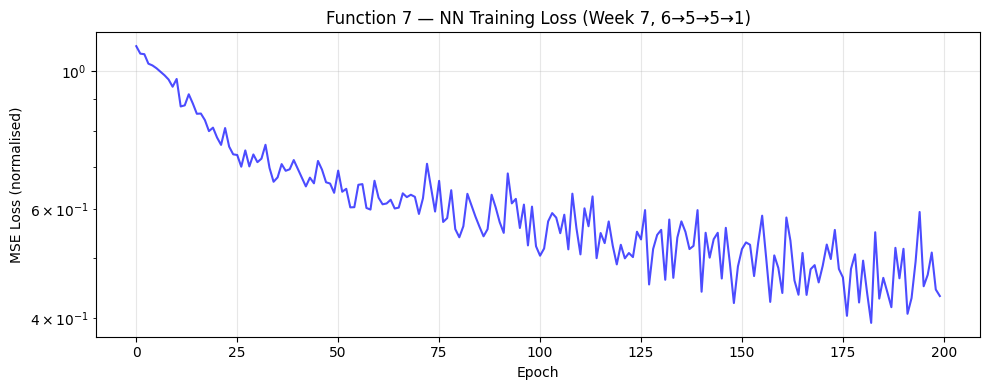


Training R²: 0.650250


In [2]:
# ── Week 7: Define & Train Neural Network ──
LEARNING_RATE = 0.005
EPOCHS = 200
DROPOUT = 0.1

class SurrogateNN(nn.Module):
    """Compact NN surrogate: 6→5→5→1 (71 parameters)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 5),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),
            nn.Linear(5, 1)
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model = SurrogateNN()
print(f"Architecture: 6→5→5→1, Parameters: {sum(p.numel() for p in model.parameters())}")

# Train with Adam, MSE loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

losses = []
model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    pred = model(X_tensor)
    loss = criterion(pred, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 40 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.6f}")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses, 'b-', alpha=0.7)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss (normalised)')
plt.title('Function 7 — NN Training Loss (Week 7, 6→5→5→1)')
plt.grid(True, alpha=0.3); plt.yscale('log')
plt.tight_layout(); plt.show()

# Training R² on original scale
model.eval()
with torch.no_grad():
    train_pred = model(X_tensor).squeeze().numpy()
train_pred_orig = train_pred * y_std + y_mean
train_r2 = 1 - np.sum((y_raw - train_pred_orig)**2) / np.sum((y_raw - y_raw.mean())**2)
print(f"\nTraining R²: {train_r2:.6f}")

In [8]:
# ── Week 7: MC Dropout EI + Interior Penalty ──
MC_SAMPLES = 50
N_CANDIDATES = 20_000
STEEPNESS = 0.1
FLOOR = 0.01

# 1. Generate random candidates in [0,1]⁶
np.random.seed(42)
candidates = np.random.uniform(0, 1.0, size=(N_CANDIDATES, 6))

# 2. Normalise candidates and run MC Dropout forward passes
cand_norm = (candidates - X_mean) / X_std
cand_tensor = torch.tensor(cand_norm, dtype=torch.float32)

model.train()  # enable dropout for MC sampling
mc_predictions = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model(cand_tensor).squeeze().numpy()
        mc_predictions.append(pred)

# 3. Un-normalise predictions to original scale
mc_preds_orig = np.array(mc_predictions) * y_std + y_mean  # (50, 20000)
mu = mc_preds_orig.mean(axis=0)     # (20000,) - MC mean
sigma = mc_preds_orig.std(axis=0)   # (20000,) - MC std

# 4. Compute EI via sample-then-average (non-parametric)
y_best = y_raw.max()
ei = np.mean(np.maximum(mc_preds_orig - y_best, 0), axis=0)  # (20000,)

# 5. Compute interior penalty weight
#    w(x) = FLOOR + (1-FLOOR) · ∏ᵢ sin(πxᵢ)^(2·STEEPNESS)
interior_weight = FLOOR + (1 - FLOOR) * np.prod(
    np.sin(np.pi * candidates) ** (2 * STEEPNESS), axis=1
)  # (20000,)

assert interior_weight.min() >= FLOOR - 1e-10, f"Min weight {interior_weight.min()} < FLOOR"
assert interior_weight.max() <= 1.0 + 1e-10, f"Max weight {interior_weight.max()} > 1.0"

# 6. Multiplicative penalty: penalised_EI = EI × w(x)
#    Works because all F7 outputs are positive → EI ≥ 0
penalised_ei = ei * interior_weight

# 7. Select best candidate (with fallback)
raw_best_idx = np.argmax(ei)
if penalised_ei.max() > 0:
    best_idx = np.argmax(penalised_ei)
else:
    # Fallback: all EI = 0 → pick most interior candidate for exploration
    best_idx = np.argmax(interior_weight)
    print("⚠ All EI = 0 — fallback to most interior candidate")

best_point = candidates[best_idx]
assert np.all(best_point >= 0) and np.all(best_point <= 1), "best_point out of [0,1]"

# 8. Report results
penalty_changed = (best_idx != raw_best_idx)
print("=== MC Dropout EI + Interior Penalty (Week 7) ===")
print(f"  y_best (observed)    = {y_best:.6f}")
print(f"  EI range             = [{ei.min():.6f}, {ei.max():.6f}]")
print(f"  Penalty weight range = [{interior_weight.min():.4f}, {interior_weight.max():.4f}]")
print(f"  Penalised EI range   = [{penalised_ei.min():.6f}, {penalised_ei.max():.6f}]")
print(f"\n  Raw EI best:        idx={raw_best_idx}, EI={ei[raw_best_idx]:.6f}, w={interior_weight[raw_best_idx]:.4f}")
print(f"  Penalised EI best:  idx={best_idx}, EI={ei[best_idx]:.6f}, w={interior_weight[best_idx]:.4f}")
print(f"  Predicted mean (μ)  = {mu[best_idx]:.6f}")
print(f"  Predicted std (σ)   = {sigma[best_idx]:.6f}")
print(f"\n  Penalty changed selection: {'YES ✓' if penalty_changed else 'NO — same candidate'}")
print(f"  Best point: {best_point}")

⚠ All EI = 0 — fallback to most interior candidate
=== MC Dropout EI + Interior Penalty (Week 7) ===
  y_best (observed)    = 2.304991
  EI range             = [0.000000, 0.000000]
  Penalty weight range = [0.0342, 0.9835]
  Penalised EI range   = [0.000000, 0.000000]

  Raw EI best:        idx=0, EI=0.000000, w=0.4732
  Penalised EI best:  idx=6239, EI=0.000000, w=0.9835
  Predicted mean (μ)  = 0.469631
  Predicted std (σ)   = 0.122698

  Penalty changed selection: YES ✓
  Best point: [0.50505163 0.56448574 0.45259003 0.45803555 0.58965013 0.52635351]


In [9]:
# ── Week 7: Feature Importance via Gradients ──
model.eval()
X_grad = torch.tensor(X_norm, dtype=torch.float32, requires_grad=True)
output = model(X_grad).sum()
output.backward()

grad_importance = X_grad.grad.abs().mean(dim=0).numpy()
grad_importance = grad_importance / grad_importance.sum()

top2 = np.argsort(grad_importance)[-2:]  # indices of two most important dims

print("=== Feature Importance (Input Gradient Magnitude, Week 7) ===")
for i, imp in enumerate(grad_importance):
    bar = '█' * int(imp * 40)
    marker = ' ◄ top-2' if i in top2 else ''
    print(f"  x{i} ({hyperparam_names[i]:>14s}): {imp:.4f} {bar}{marker}")

=== Feature Importance (Input Gradient Magnitude, Week 7) ===
  x0 ( learning_rate): 0.2300 █████████ ◄ top-2
  x1 (  reg_strength): 0.0851 ███
  x2 (      n_layers): 0.2022 ████████ ◄ top-2
  x3 (       dropout): 0.1452 █████
  x4 (    batch_size): 0.1685 ██████
  x5 (     optimizer): 0.1689 ██████


Top-2 dims: x2 (n_layers), x0 (learning_rate)
Fixed: x1=0.2618, x3=0.1736, x4=0.3524, x5=0.6873


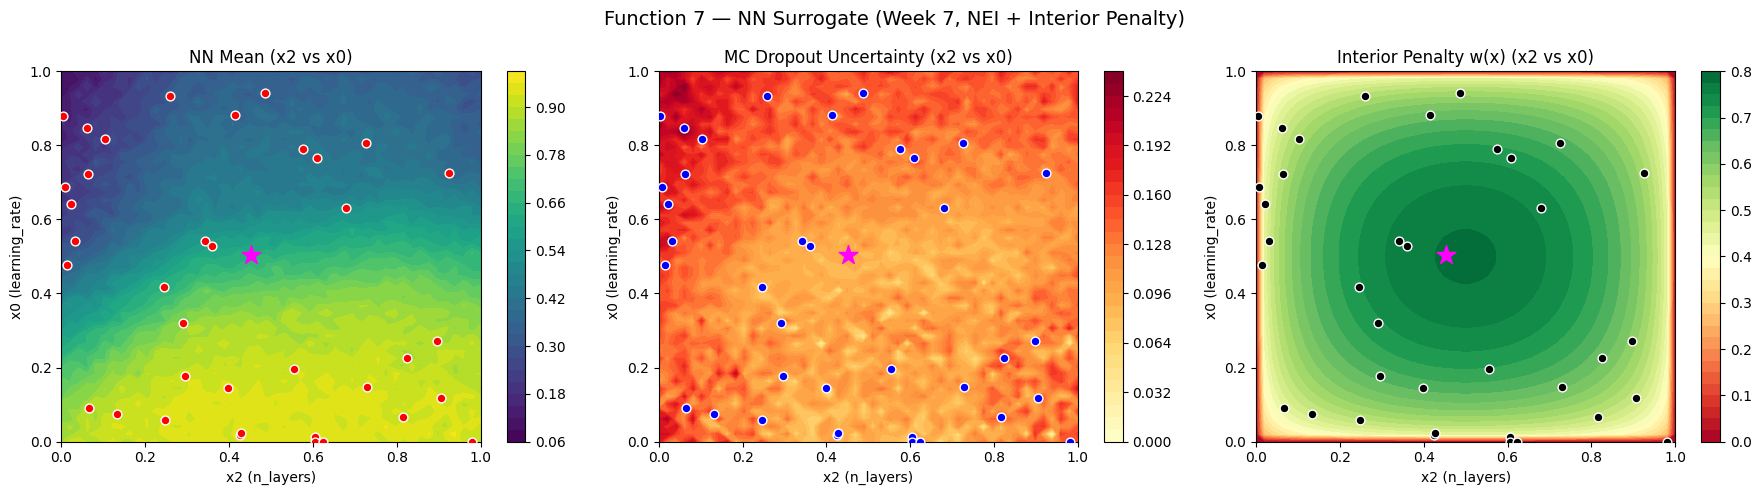

In [11]:
# ── Week 7: 3-Panel Visualisation (NN Mean, MC Uncertainty, Interior Penalty) ──
fixed_dims = [d for d in range(6) if d not in top2]
best_obs = X_raw[y_raw.argmax()]

print(f"Top-2 dims: x{top2[0]} ({hyperparam_names[top2[0]]}), x{top2[1]} ({hyperparam_names[top2[1]]})")
print(f"Fixed: " + ", ".join(f"x{d}={best_obs[d]:.4f}" for d in fixed_dims))

# Build 50×50 grid on top-2 dimensions
n_grid = 50
g0 = np.linspace(0, 1, n_grid)
g1 = np.linspace(0, 1, n_grid)
G0, G1 = np.meshgrid(g0, g1)

grid_pts = np.zeros((n_grid * n_grid, 6))
grid_pts[:, top2[0]] = G0.ravel()
grid_pts[:, top2[1]] = G1.ravel()
for d in fixed_dims:
    grid_pts[:, d] = best_obs[d]

# MC Dropout predictions on grid
grid_norm = (grid_pts - X_mean) / X_std
grid_tensor = torch.tensor(grid_norm, dtype=torch.float32)

model.train()  # enable dropout
grid_mc = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model(grid_tensor).squeeze().numpy()
        grid_mc.append(pred)
grid_mc = np.array(grid_mc) * y_std + y_mean

grid_mu = grid_mc.mean(axis=0).reshape(n_grid, n_grid)
grid_sigma = grid_mc.std(axis=0).reshape(n_grid, n_grid)

# Interior penalty on grid
grid_penalty = FLOOR + (1 - FLOOR) * np.prod(
    np.sin(np.pi * grid_pts) ** (2 * STEEPNESS), axis=1
).reshape(n_grid, n_grid)

# Plot 3 panels
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: NN Mean
c1 = axes[0].contourf(G0, G1, grid_mu, levels=30, cmap='viridis')
axes[0].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c='red', edgecolors='white', s=40, zorder=5)
axes[0].scatter(best_point[top2[0]], best_point[top2[1]], c='magenta', marker='*', s=200, zorder=6)
axes[0].set_title(f"NN Mean (x{top2[0]} vs x{top2[1]})")
axes[0].set_xlabel(f"x{top2[0]} ({hyperparam_names[top2[0]]})")
axes[0].set_ylabel(f"x{top2[1]} ({hyperparam_names[top2[1]]})")
fig.colorbar(c1, ax=axes[0])

# Panel 2: MC Dropout Uncertainty
c2 = axes[1].contourf(G0, G1, grid_sigma, levels=30, cmap='YlOrRd')
axes[1].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c='blue', edgecolors='white', s=40, zorder=5)
axes[1].scatter(best_point[top2[0]], best_point[top2[1]], c='magenta', marker='*', s=200, zorder=6)
axes[1].set_title(f"MC Dropout Uncertainty (x{top2[0]} vs x{top2[1]})")
axes[1].set_xlabel(f"x{top2[0]} ({hyperparam_names[top2[0]]})")
axes[1].set_ylabel(f"x{top2[1]} ({hyperparam_names[top2[1]]})")
fig.colorbar(c2, ax=axes[1])

# Panel 3: Interior Penalty Heatmap
c3 = axes[2].contourf(G0, G1, grid_penalty, levels=30, cmap='RdYlGn')
axes[2].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c='black', edgecolors='white', s=40, zorder=5)
axes[2].scatter(best_point[top2[0]], best_point[top2[1]], c='magenta', marker='*', s=200, zorder=6)
axes[2].set_title(f"Interior Penalty w(x) (x{top2[0]} vs x{top2[1]})")
axes[2].set_xlabel(f"x{top2[0]} ({hyperparam_names[top2[0]]})")
axes[2].set_ylabel(f"x{top2[1]} ({hyperparam_names[top2[1]]})")
fig.colorbar(c3, ax=axes[2])

plt.suptitle("Function 7 — NN Surrogate (Week 7, NEI + Interior Penalty)", fontsize=14)
plt.tight_layout()
plt.show()

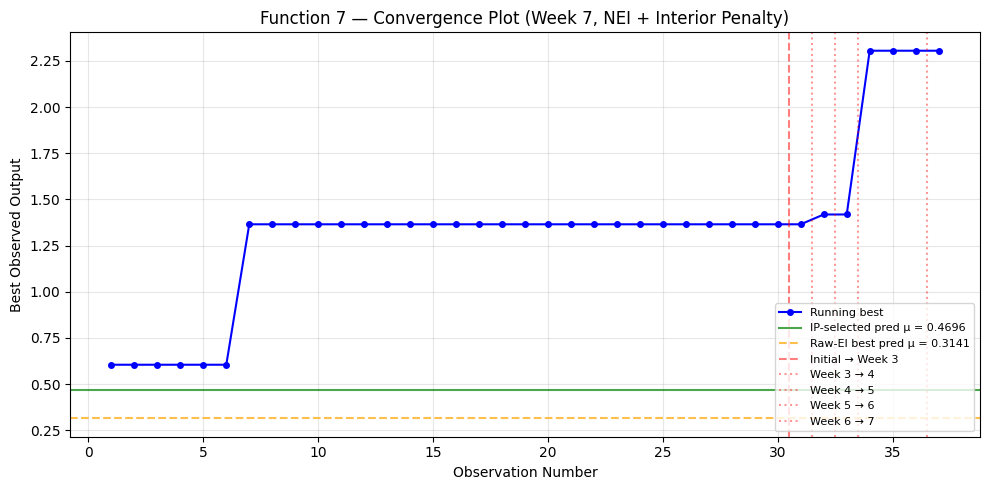

Running best at Week 6 end (sample 36): 2.304991
Running best at Week 7 end (sample 37): 2.304991
IP-selected predicted mean: 0.469631
Penalty changed selection: YES ✓


In [12]:
# ── Week 7: Convergence Plot ──
running_best = np.maximum.accumulate(y_raw)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_raw) + 1), running_best, 'b-o', markersize=4, linewidth=1.5, label='Running best')

# IP-selected candidate predicted mean
plt.axhline(y=mu[best_idx], color='green', linestyle='-', alpha=0.7,
            label=f'IP-selected pred μ = {mu[best_idx]:.4f}')
# Raw-EI best candidate predicted mean (comparison)
plt.axhline(y=mu[raw_best_idx], color='orange', linestyle='--', alpha=0.7,
            label=f'Raw-EI best pred μ = {mu[raw_best_idx]:.4f}')

# Weekly data boundaries
plt.axvline(x=30.5, color="red", linestyle="--", alpha=0.5, label="Initial → Week 3")
plt.axvline(x=31.5, color="red", linestyle=":", alpha=0.4, label="Week 3 → 4")
plt.axvline(x=32.5, color="red", linestyle=":", alpha=0.4, label="Week 4 → 5")
plt.axvline(x=33.5, color="red", linestyle=":", alpha=0.4, label="Week 5 → 6")
plt.axvline(x=36.5, color="red", linestyle=":", alpha=0.4, label="Week 6 → 7")

plt.xlabel("Observation Number")
plt.ylabel("Best Observed Output")
plt.title("Function 7 — Convergence Plot (Week 7, NEI + Interior Penalty)")
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Running best at Week 6 end (sample 36): {running_best[35]:.6f}")
print(f"Running best at Week 7 end (sample 37): {running_best[-1]:.6f}")
print(f"IP-selected predicted mean: {mu[best_idx]:.6f}")
print(f"Penalty changed selection: {'YES ✓' if penalty_changed else 'NO'}")

In [13]:
# ── Week 7: Submission Query ──
submission_point = np.clip(best_point, 0.0, 0.999999)
submission_query = "-".join(f"{v:.6f}" for v in submission_point)

print("=" * 60)
print("WEEK 7 SUBMISSION QUERY FOR FUNCTION 7")
print("=" * 60)
print(f"\n  {submission_query}\n")
print("=" * 60)

# Format validation
parts = submission_query.split("-")
assert len(parts) == 6, f"Expected 6 dimensions, got {len(parts)}"
for p in parts:
    v = float(p)
    assert 0.0 <= v <= 0.999999, f"Value {v} out of bounds [0, 0.999999]"
print("✓ Submission format validated (6 dims, all in [0, 0.999999])")

# Hyperparameter metadata
print(f"\n── Hyperparameters ──")
print(f"  Architecture: 6→5→5→1 (71 params)")
print(f"  Learning rate: {LEARNING_RATE}, Dropout: {DROPOUT}, Epochs: {EPOCHS}")
print(f"  MC samples: {MC_SAMPLES}, Candidates: {N_CANDIDATES:,}")
print(f"  STEEPNESS: {STEEPNESS}, FLOOR: {FLOOR}")
print(f"  Training R²: {train_r2:.6f}")

# Penalty effect
print(f"\n── Penalty Effect ──")
print(f"  Raw EI best:       [{'-'.join(f'{v:.6f}' for v in candidates[raw_best_idx])}]")
print(f"    EI={ei[raw_best_idx]:.6f}, w={interior_weight[raw_best_idx]:.4f}, penalised={penalised_ei[raw_best_idx]:.6f}")
print(f"  IP-selected:       [{'-'.join(f'{v:.6f}' for v in best_point)}]")
print(f"    EI={ei[best_idx]:.6f}, w={interior_weight[best_idx]:.4f}, penalised={penalised_ei[best_idx]:.6f}")
print(f"  Selection changed: {'YES ✓' if penalty_changed else 'NO'}")

# Per-dimension breakdown
print(f"\n── Per-Dimension Coordinates ──")
for i, (name, val) in enumerate(zip(hyperparam_names, submission_point)):
    print(f"  x{i} ({name:>14s}): {val:.6f}")

WEEK 7 SUBMISSION QUERY FOR FUNCTION 7

  0.505052-0.564486-0.452590-0.458036-0.589650-0.526354

✓ Submission format validated (6 dims, all in [0, 0.999999])

── Hyperparameters ──
  Architecture: 6→5→5→1 (71 params)
  Learning rate: 0.005, Dropout: 0.1, Epochs: 200
  MC samples: 50, Candidates: 20,000
  STEEPNESS: 0.1, FLOOR: 0.01
  Training R²: 0.650250

── Penalty Effect ──
  Raw EI best:       [0.374540-0.950714-0.731994-0.598658-0.156019-0.155995]
    EI=0.000000, w=0.4732, penalised=0.000000
  IP-selected:       [0.505052-0.564486-0.452590-0.458036-0.589650-0.526354]
    EI=0.000000, w=0.9835, penalised=0.000000
  Selection changed: YES ✓

── Per-Dimension Coordinates ──
  x0 ( learning_rate): 0.505052
  x1 (  reg_strength): 0.564486
  x2 (      n_layers): 0.452590
  x3 (       dropout): 0.458036
  x4 (    batch_size): 0.589650
  x5 (     optimizer): 0.526354
